In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '/ceph/MethDev/pbio/hazel/gene_mcds/gene'
rna_path = '/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv'
meta_path = '/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

In [2]:
with open('extracted_c1039_gene.txt', 'r') as file:
    # .strip() removes spaces and \n characters, and we ignore empty lines
    my_gene_list = [line.strip() for line in file if line.strip()]

print(f"Successfully loaded {len(my_gene_list)} genes from hazel_list.txt.")

Successfully loaded 1238 genes from hazel_list.txt.


# cluster_rna_matrix

In [3]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


# filtered_meth_df

In [4]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [5]:
import statsmodels.api as sm
from scipy.stats import zscore

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


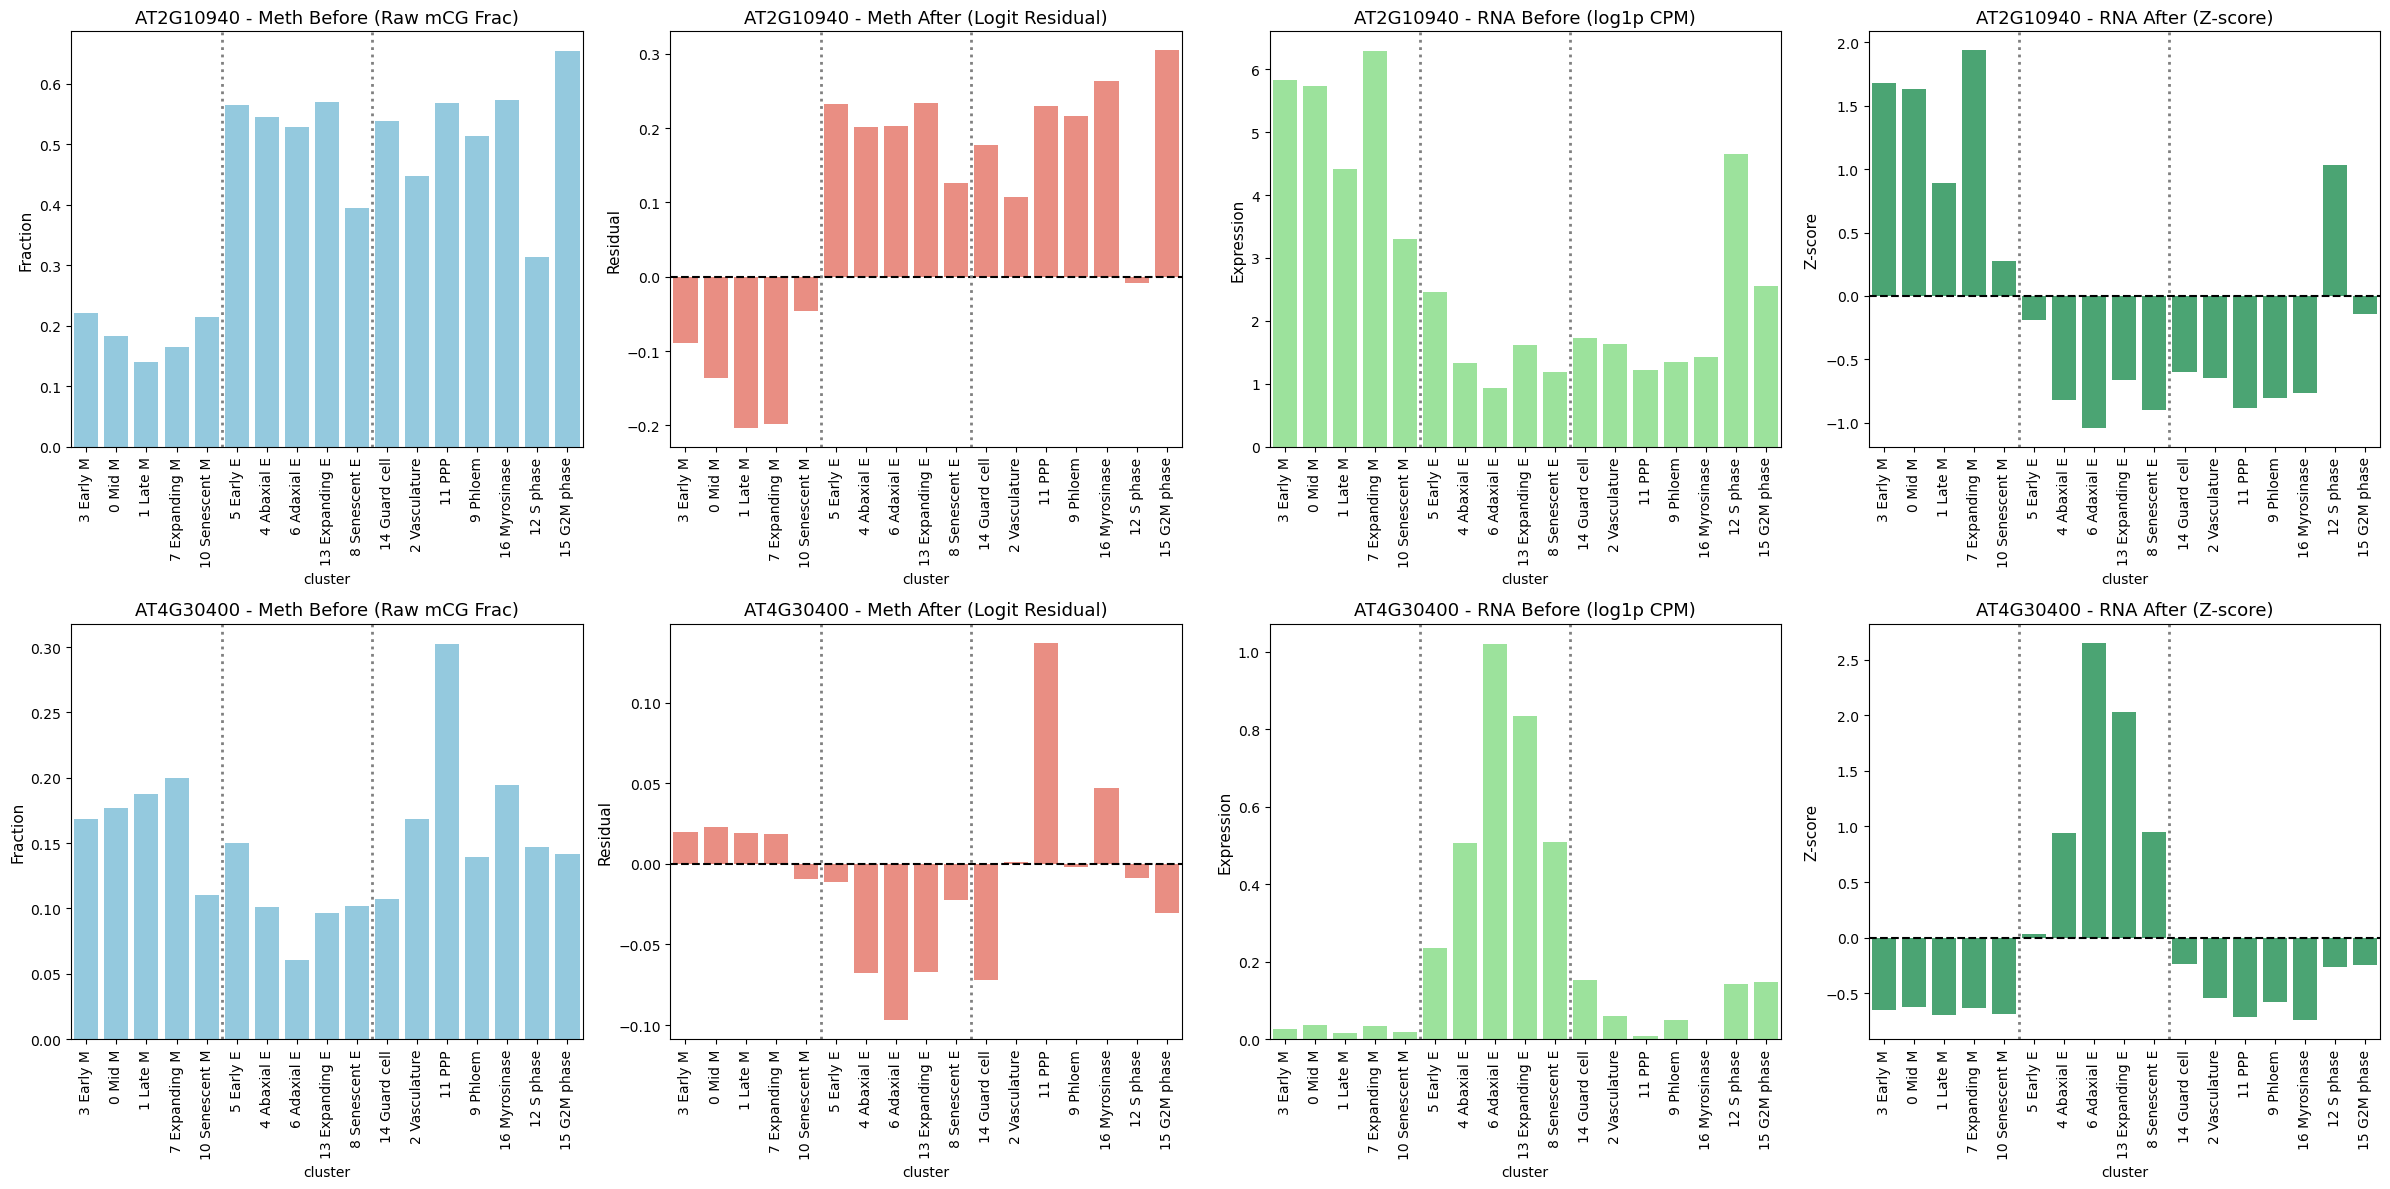

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore

genes_to_check = ['AT2G10940', 'AT4G30400']

# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '1 Late M', '7 Expanding M', '10 Senescent M',
    '5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

fig, axes = plt.subplots(len(genes_to_check), 4, figsize=(24, 6 * len(genes_to_check)))

if len(genes_to_check) == 1:
    axes = [axes]

for i, gene in enumerate(genes_to_check):
    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene].rename(index=cluster_mapping)
        meth_adj = adj_meth_matrix.loc[gene].rename(index=cluster_mapping)
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)
        
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene].rename(index=cluster_mapping)
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG Frac)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=90)
    
    # --- Panel 2: Methylation After ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=90)

    # --- Panel 3: RNA Before ---
    ax3 = axes[i, 2]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax3, color='lightgreen')
        ax3.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax3.set_ylabel("Expression", fontsize=11)
    else:
        ax3.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax3.tick_params(axis='x', rotation=90)

    # --- Panel 4: RNA After ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax4, color='mediumseagreen')
        ax4.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax4.set_ylabel("Z-score", fontsize=11)
        ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax4.tick_params(axis='x', rotation=90)

    # Add vertical dividers to separate cell types visually
    for ax in [ax1, ax2, ax3, ax4]:
        ax.axvline(4.5, color='gray', linestyle=':', lw=2) # Divider after Mesophyll
        ax.axvline(9.5, color='gray', linestyle=':', lw=2) # Divider after Epidermis

plt.tight_layout()
plt.show()

--- Stats for AT4G30400 ---
Rank: 44.0 out of 12742
Rho (Spearman): -1.0846
P-value: 2.7626e-06
FDR: 2.5144e-03

--- Top 5 Ranked Genes for Comparison ---
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529




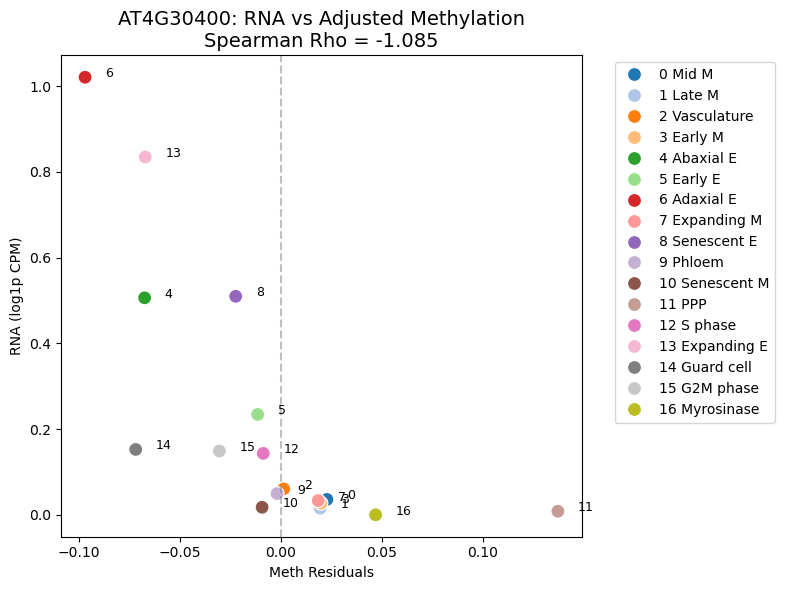

In [7]:
target_gene = 'AT4G30400'

# 1. Check where the gene ranks
stats_sorted = stats_df.sort_values('rho')
stats_sorted['rank'] = range(1, len(stats_sorted) + 1)

if target_gene in stats_sorted.index:
    target_stats = stats_sorted.loc[target_gene]
    print(f"--- Stats for {target_gene} ---")
    print(f"Rank: {target_stats['rank']} out of {len(stats_sorted)}")
    print(f"Rho (Spearman): {target_stats['rho']:.4f}")
    print(f"P-value: {target_stats['p_value']:.4e}")
    print(f"FDR: {target_stats['fdr']:.4e}\n")
else:
    print(f"{target_gene} not found in stats_df (failed coverage or variance filters).")

print("--- Top 5 Ranked Genes for Comparison ---")
print(stats_sorted[['rho', 'p_value', 'fdr']].head(5))
print("\n")

# 2. Visualize the exact Scatter of Ranks for the target gene
if target_gene in final_rna_df.index and target_gene in final_meth_df.index:
    rna_vals = final_rna_df.loc[target_gene]
    meth_vals = final_meth_df.loc[target_gene]
    
    # Create a dataframe for plotting
    plot_df = pd.DataFrame({
        'RNA (log1p CPM)': rna_vals,
        'Meth Residuals': meth_vals,
        'Cluster': [cluster_mapping.get(c, str(c)) for c in rna_vals.index]
    })
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x='Meth Residuals', y='RNA (log1p CPM)', 
                    s=100, hue='Cluster', palette='tab20', ax=ax)
    
    # Annotate points to see which clusters break the rank order
    for i, row in plot_df.iterrows():
        ax.text(row['Meth Residuals'] + 0.01, row['RNA (log1p CPM)'], 
                row['Cluster'].split(' ')[0], # Just print the cluster number to save space
                fontsize=9)
        
    ax.set_title(f"{target_gene}: RNA vs Adjusted Methylation\nSpearman Rho = {target_stats['rho']:.3f}", fontsize=14)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Place legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Plotting top 300 genes with the strongest negative WLS correlation.


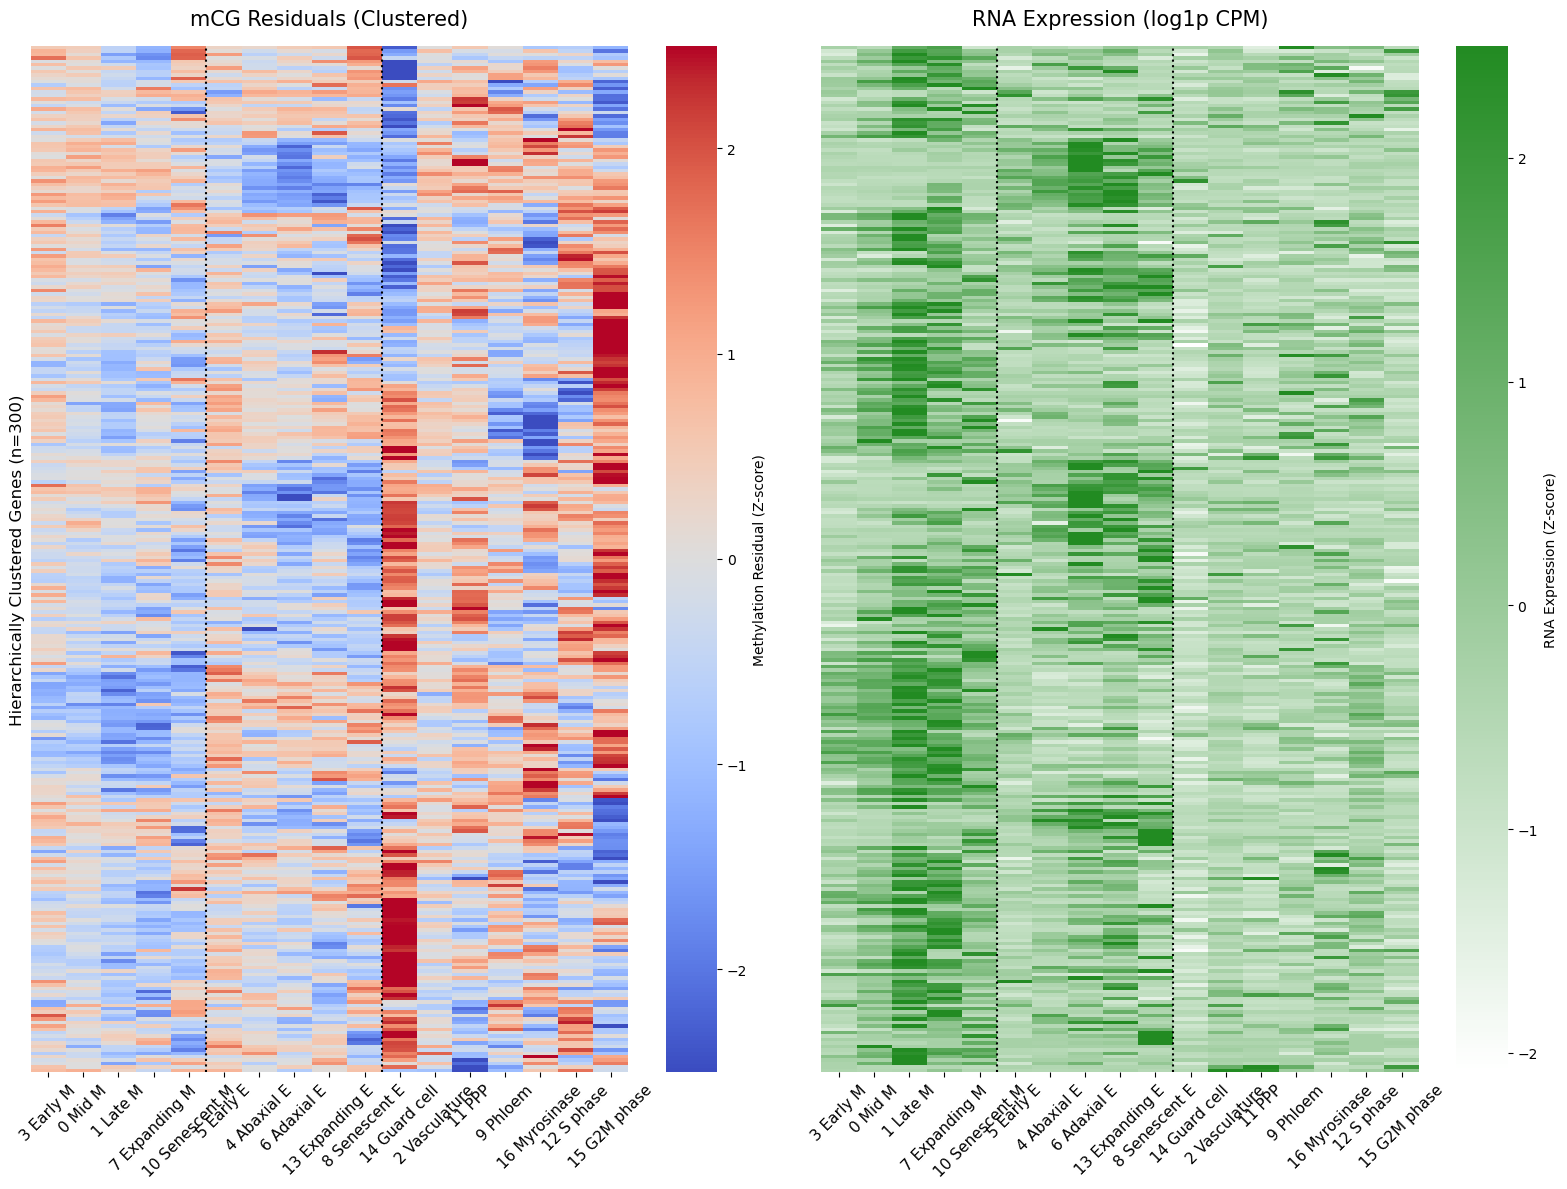

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df.sort_values('rho').head(300).index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

valid_order = [c for c in cluster_order if c in vis_meth_sorted.columns]
vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
# We cluster based on the methylation patterns to group similar regulatory states together
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Grey_to_Green", ["white", "forestgreen"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)

# RNA Expression Heatmap (Grey to Green)
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=45, labelsize=11)

# Add visual dividers for Mesophyll and Epidermis groupings
for ax in [ax1, ax2]:
    ax.axvline(5, color='black', lw=1.5, linestyle=':')  # After Senescent M
    ax.axvline(10, color='black', lw=1.5, linestyle=':') # After Senescent E

plt.tight_layout()
plt.savefig("rna_meth_wls_top300_clustered_heatmap.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

Plotting top 300 genes with the strongest negative WLS correlation.


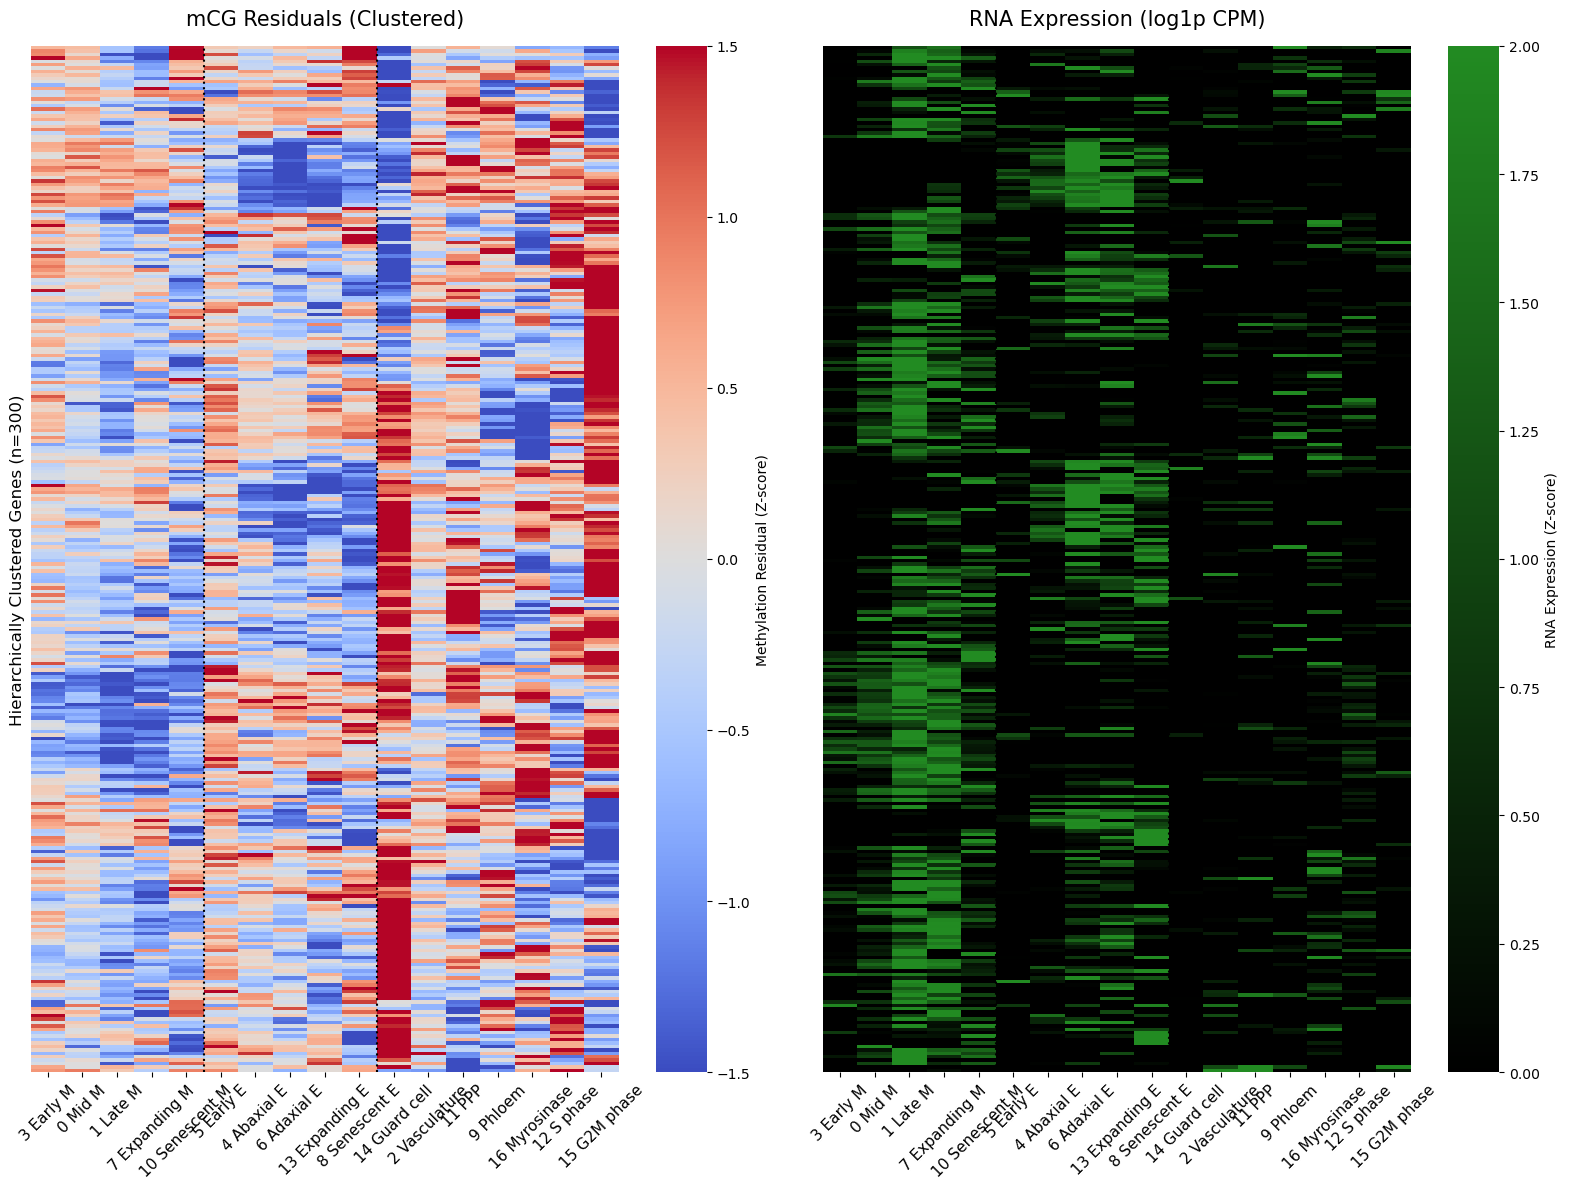

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df.sort_values('rho').head(300).index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    # This clipping is crucial so outliers don't ruin the hierarchical clustering!
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

valid_order = [c for c in cluster_order if c in vis_meth_sorted.columns]
vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
# We cluster based on the methylation patterns to group similar regulatory states together
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Grey_to_Green", ["black", "forestgreen"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
# Methylation Heatmap (Tightened to -1.5 to 1.5)
# You can change this to -1.0 and 1.0 if it needs even more contrast
sns.heatmap(vis_meth_clustered, cmap="coolwarm", ax=ax1, 
            vmin=-1.5, vmax=1.5, center=0,
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)

# RNA Expression Heatmap (Floored at 0, capped at 2)
# Negative Z-scores become pure white, positive values transition to dark green
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            vmin=0, vmax=2.0, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=45, labelsize=11)

# Add visual dividers
for ax in [ax1, ax2]:
    ax.axvline(5, color='black', lw=1.5, linestyle=':')  # After Senescent M
    ax.axvline(10, color='black', lw=1.5, linestyle=':') # After Senescent E

plt.tight_layout()
plt.savefig("rna_meth_wls_top300_high_contrast.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
stats_df[stats_df["p_value"]<0.05]

,rho,p_value,fdr
gene,,,
AT1G01240,-1.029007,0.005252,0.242366
AT1G01790,0.699194,0.014027,0.340442
AT1G01970,0.487750,0.047432,0.495169
AT1G02010,0.683823,0.034456,0.451871
AT1G02110,-0.765909,0.000134,0.034907
...,...,...,...
AT5G65760,0.850481,0.023996,0.398737
AT5G65780,0.866484,0.000157,0.038578
AT5G65930,0.491865,0.038484,0.466139


In [11]:
stats_df[stats_df["p_value"]<0.05]

,rho,p_value,fdr
gene,,,
AT1G01240,-1.029007,0.005252,0.242366
AT1G01790,0.699194,0.014027,0.340442
AT1G01970,0.487750,0.047432,0.495169
AT1G02010,0.683823,0.034456,0.451871
AT1G02110,-0.765909,0.000134,0.034907
...,...,...,...
AT5G65760,0.850481,0.023996,0.398737
AT5G65780,0.866484,0.000157,0.038578
AT5G65930,0.491865,0.038484,0.466139


In [14]:
#test

Plotting top 1270 genes with the strongest negative WLS correlation.


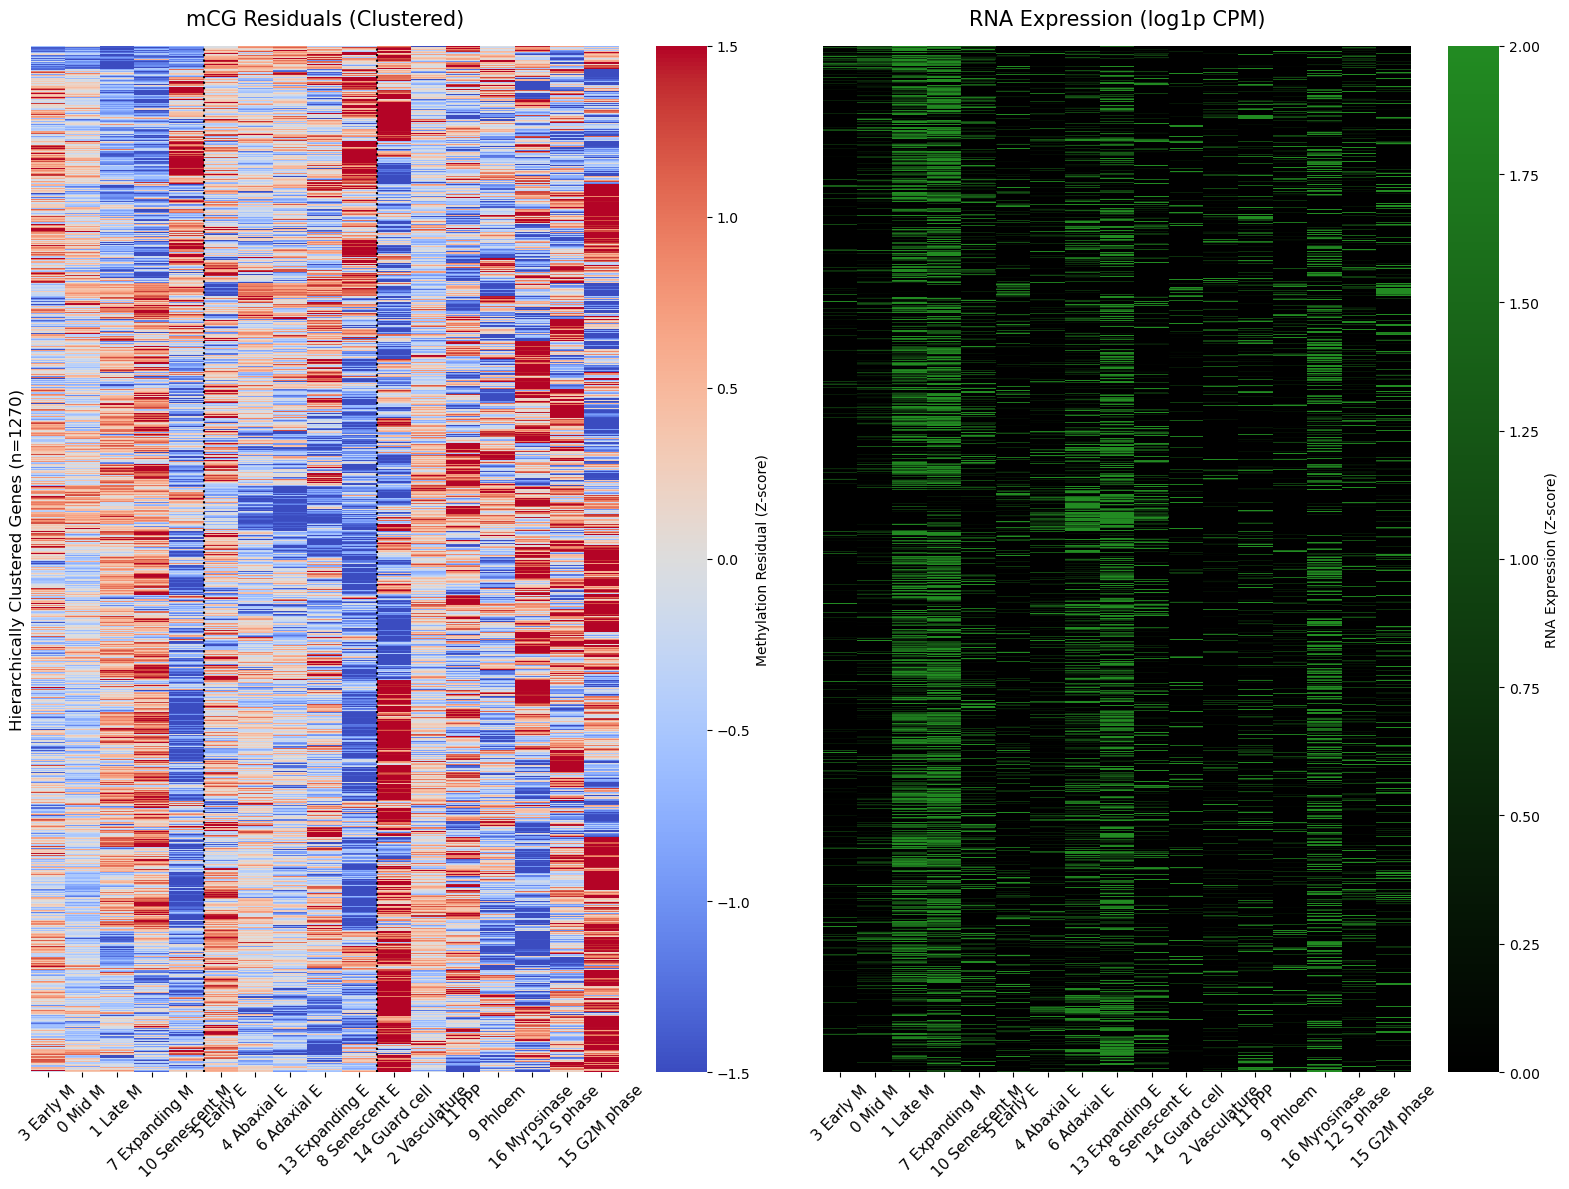

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df[stats_df["p_value"]<0.05].index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    # This clipping is crucial so outliers don't ruin the hierarchical clustering!
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

valid_order = [c for c in cluster_order if c in vis_meth_sorted.columns]
vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
# We cluster based on the methylation patterns to group similar regulatory states together
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Grey_to_Green", ["black", "forestgreen"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
# Methylation Heatmap (Tightened to -1.5 to 1.5)
# You can change this to -1.0 and 1.0 if it needs even more contrast
sns.heatmap(vis_meth_clustered, cmap="coolwarm", ax=ax1, 
            vmin=-1.5, vmax=1.5, center=0,
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)

# RNA Expression Heatmap (Floored at 0, capped at 2)
# Negative Z-scores become pure white, positive values transition to dark green
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            vmin=0, vmax=2.0, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=45, labelsize=11)

# Add visual dividers
for ax in [ax1, ax2]:
    ax.axvline(5, color='black', lw=1.5, linestyle=':')  # After Senescent M
    ax.axvline(10, color='black', lw=1.5, linestyle=':') # After Senescent E

plt.tight_layout()
plt.savefig("rna_meth_wls_top300_high_contrast.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

Plotting top 426 genes with the strongest negative WLS correlation.


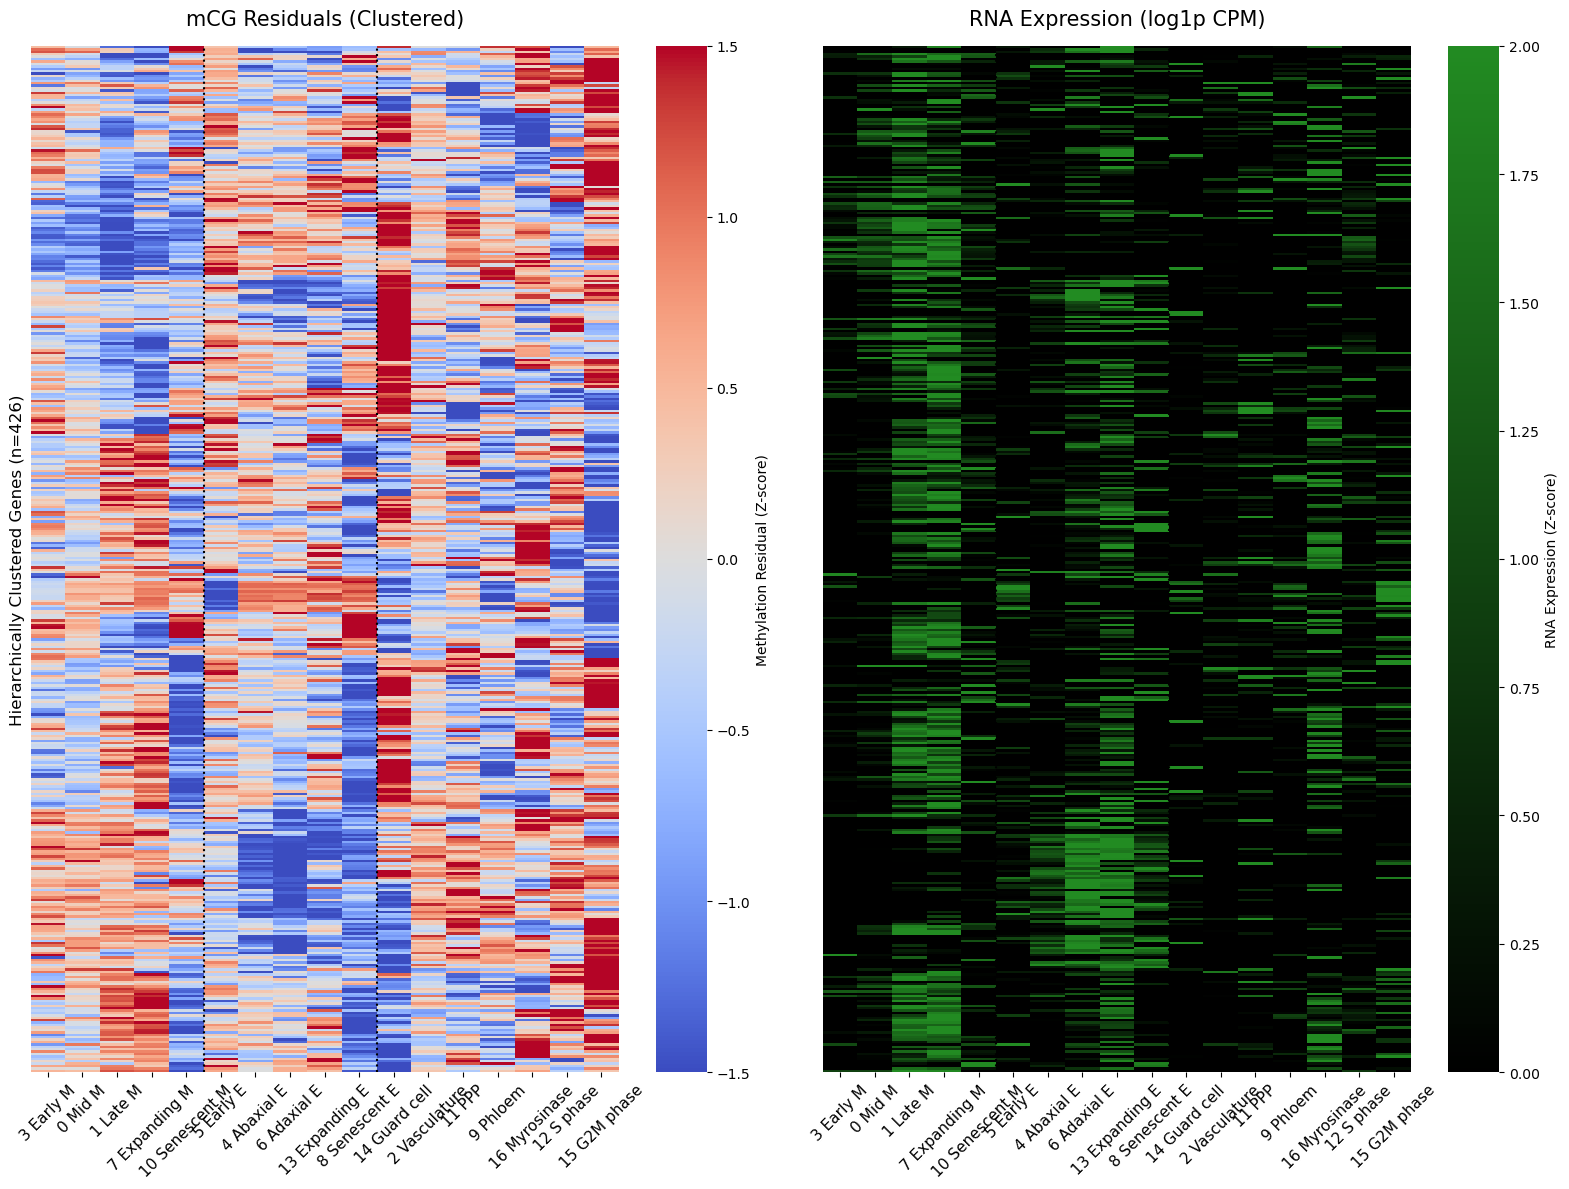

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df[stats_df["p_value"]<0.01].index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    # This clipping is crucial so outliers don't ruin the hierarchical clustering!
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

valid_order = [c for c in cluster_order if c in vis_meth_sorted.columns]
vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
# We cluster based on the methylation patterns to group similar regulatory states together
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Grey_to_Green", ["black", "forestgreen"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
# Methylation Heatmap (Tightened to -1.5 to 1.5)
# You can change this to -1.0 and 1.0 if it needs even more contrast
sns.heatmap(vis_meth_clustered, cmap="coolwarm", ax=ax1, 
            vmin=-1.5, vmax=1.5, center=0,
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)

# RNA Expression Heatmap (Floored at 0, capped at 2)
# Negative Z-scores become pure white, positive values transition to dark green
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            vmin=0, vmax=2.0, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=45, labelsize=11)

# Add visual dividers
for ax in [ax1, ax2]:
    ax.axvline(5, color='black', lw=1.5, linestyle=':')  # After Senescent M
    ax.axvline(10, color='black', lw=1.5, linestyle=':') # After Senescent E

plt.tight_layout()
plt.savefig("rna_meth_wls_top300_high_contrast.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
def identify_relative_lows(gene_list, obs_p, adj_meth_matrix, cluster_m, 
                           min_coverage=10, 
                           residual_threshold=-0.05,    # RELAXED: Only require a 5% drop
                           zscore_threshold=-1.0,       # RELAXED: Only 1 standard dev below mean
                           min_raw_max=0.05):           # RELAXED: Gene only needs 5% max methylation
    results = []
    valid_genes = [g for g in gene_list if g in adj_meth_matrix.index]
    
    for gene in valid_genes:
        gene_obs = obs_p.loc[gene]
        gene_adj = adj_meth_matrix.loc[gene]
        gene_cov = cluster_m.loc[gene]
        
        # Relaxed global unmethylated check
        if gene_obs.max() < min_raw_max:
            continue
            
        valid_clusters_mask = gene_cov >= min_coverage
        if valid_clusters_mask.sum() < 3:
            continue 
            
        valid_adj = gene_adj[valid_clusters_mask]
        adj_zscores = pd.Series(zscore(valid_adj), index=valid_adj.index)
        
        # Apply relaxed thresholds
        hypo_clusters = valid_adj[(valid_adj <= residual_threshold) & (adj_zscores <= zscore_threshold)].index.tolist()
        
        if hypo_clusters:
            for cluster in hypo_clusters:
                results.append({
                    'Gene': gene,
                    'Cluster': cluster,
                    'Raw_Fraction': gene_obs[cluster],
                    'Residual': valid_adj[cluster],
                    'Z_Score': adj_zscores[cluster],
                    'Coverage': gene_cov[cluster]
                })
                
    if not results:
        return pd.DataFrame()
    return pd.DataFrame(results).sort_values(by=['Gene', 'Residual'])

# --- Run with Relaxed Parameters for AT4G30400 ---
relaxed_results = identify_relative_lows(
    gene_list=['AT4G30400'],
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    residual_threshold=-0.03,  # Just a 3% absolute drop required
    zscore_threshold=-1.0,     # 1 standard deviation below its own mean
    min_raw_max=0.00           # Turn off the "must be methylated somewhere" filter completely
)

display(relaxed_results)

,Gene,Cluster,Raw_Fraction,Residual,Z_Score,Coverage
1,AT4G30400,6.0,0.060750,-0.097046,-1.705512,2535
3,AT4G30400,14.0,0.107362,-0.071955,-1.229108,326
0,AT4G30400,4.0,0.100870,-0.067541,-1.145306,3906
2,AT4G30400,13.0,0.096386,-0.067230,-1.139404,830


In [18]:
import pandas as pd

# 1. Run the function on all aligned genes to capture all hypomethylation events
all_hypo_results = identify_relative_lows(
    gene_list=common_genes,       # Using all genes present in both modalities
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    residual_threshold=-0.05,     # Adjust these thresholds if you want them stricter/looser
    zscore_threshold=-1.0,     
    min_raw_max=0.05           
)

# 2. Group the results by cluster and extract the gene names
cluster_gene_dict = {}
for cluster_id, group in all_hypo_results.groupby('Cluster'):
    # Map the numeric cluster ID to your descriptive string name
    cluster_name = cluster_mapping.get(cluster_id, str(cluster_id))
    # Extract the unique genes for this cluster
    cluster_gene_dict[cluster_name] = group['Gene'].unique().tolist()

# 3. Assemble into a DataFrame, padding uneven columns with NaNs
hypo_genes_by_cluster_df = pd.DataFrame({
    cluster: pd.Series(genes) 
    for cluster, genes in cluster_gene_dict.items()
})

# 4. Optional: Reorder the columns to match your preferred biological order
valid_cols = [c for c in cluster_order if c in hypo_genes_by_cluster_df.columns]
hypo_genes_by_cluster_df = hypo_genes_by_cluster_df[valid_cols]

# Display the resulting table
display(hypo_genes_by_cluster_df.head(10))

# To save this table to a CSV for external use:
hypo_genes_by_cluster_df.to_csv("/ceph/MethDev/pbio/kay/data/hypomethylated_genes_by_cluster.csv", index=False)

,3 Early M,0 Mid M,1 Late M,7 Expanding M,10 Senescent M,5 Early E,4 Abaxial E,6 Adaxial E,13 Expanding E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
0,AT1G04953,AT1G01046,AT1G07117,AT1G01530,AT1G01040,AT1G04497,AT1G02110,AT1G02110,AT1G01040,AT1G01040,AT1G01150,AT1G06673,AT1G01440,AT1G01046,AT1G01350,AT1G01530,AT1G01450
1,AT1G05307,AT1G06673,AT1G07137,AT1G03200,AT1G01970,AT1G05250,AT1G05733,AT1G02500,AT1G01046,AT1G01350,AT1G01260,AT1G06727,AT1G01530,AT1G02010,AT1G01530,AT1G01750,AT1G02050
2,AT1G06417,AT1G07537,AT1G07333,AT1G06727,AT1G02500,AT1G05307,AT1G06293,AT1G04293,AT1G01320,AT1G01750,AT1G02050,AT1G07193,AT1G02470,AT1G03200,AT1G02430,AT1G02100,AT1G02910
3,AT1G06987,AT1G20470,AT1G08237,AT1G07117,AT1G03060,AT1G06617,AT1G06347,AT1G04547,AT1G01970,AT1G02110,AT1G02260,AT1G32520,AT1G03240,AT1G03240,AT1G03100,AT1G02470,AT1G03100
4,AT1G07317,AT1G33010,AT1G11860,AT1G07537,AT1G03810,AT1G06977,AT1G06653,AT1G05733,AT1G02110,AT1G02890,AT1G02280,AT1G36085,AT1G04293,AT1G03810,AT1G03510,AT1G03475,AT1G03470
5,AT1G07457,AT1G36756,AT1G20470,AT1G08367,AT1G03830,AT1G07017,AT1G06667,AT1G06347,AT1G02280,AT1G03060,AT1G02430,AT1G43825,AT1G05047,AT1G03910,AT1G03530,AT1G03510,AT1G03560
6,AT1G07463,AT1G37113,AT1G23720,AT1G08647,AT1G04027,AT1G07583,AT1G06673,AT1G06417,AT1G02500,AT1G03810,AT1G02910,AT1G49225,AT1G05070,AT1G03930,AT1G03810,AT1G04053,AT1G04057
7,AT1G07777,AT1G45242,AT1G25150,AT1G08813,AT1G04050,AT1G07637,AT1G07193,AT1G06447,AT1G04117,AT1G03910,AT1G03200,AT1G49230,AT1G05410,AT1G04027,AT1G04003,AT1G04157,AT1G04063
8,AT1G08237,AT1G47580,AT1G29910,AT1G12020,AT1G04063,AT1G07777,AT1G07243,AT1G06623,AT1G04303,AT1G04027,AT1G03560,AT1G53683,AT1G05783,AT1G04083,AT1G04050,AT1G04303,AT1G04163
9,AT1G08333,AT1G59453,AT1G36030,AT1G29435,AT1G04083,AT1G07893,AT1G07293,AT1G06777,AT1G05087,AT1G04053,AT1G04057,AT1G60989,AT1G05867,AT1G04157,AT1G04160,AT1G04577,AT1G04297


In [17]:
hypo_genes_by_cluster_df

,3 Early M,0 Mid M,1 Late M,7 Expanding M,10 Senescent M,5 Early E,4 Abaxial E,6 Adaxial E,13 Expanding E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
0,AT1G04953,AT1G01046,AT1G07117,AT1G01530,AT1G01040,AT1G04497,AT1G02110,AT1G02110,AT1G01040,AT1G01040,AT1G01150,AT1G06673,AT1G01440,AT1G01046,AT1G01350,AT1G01530,AT1G01450
1,AT1G05307,AT1G06673,AT1G07137,AT1G03200,AT1G01970,AT1G05250,AT1G05733,AT1G02500,AT1G01046,AT1G01350,AT1G01260,AT1G06727,AT1G01530,AT1G02010,AT1G01530,AT1G01750,AT1G02050
2,AT1G06417,AT1G07537,AT1G07333,AT1G06727,AT1G02500,AT1G05307,AT1G06293,AT1G04293,AT1G01320,AT1G01750,AT1G02050,AT1G07193,AT1G02470,AT1G03200,AT1G02430,AT1G02100,AT1G02910
3,AT1G06987,AT1G20470,AT1G08237,AT1G07117,AT1G03060,AT1G06617,AT1G06347,AT1G04547,AT1G01970,AT1G02110,AT1G02260,AT1G32520,AT1G03240,AT1G03240,AT1G03100,AT1G02470,AT1G03100
4,AT1G07317,AT1G33010,AT1G11860,AT1G07537,AT1G03810,AT1G06977,AT1G06653,AT1G05733,AT1G02110,AT1G02890,AT1G02280,AT1G36085,AT1G04293,AT1G03810,AT1G03510,AT1G03475,AT1G03470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AT5G67340,NaN,NaN
1650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ATMG00810,NaN,NaN
1651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ATMG00960,NaN,NaN
1652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ATMG01110,NaN,NaN


--- Hypomethylation Summary ---
Total unique hypomethylated genes: 5983

Number of hypomethylated genes per cluster:
3 Early M          116
0 Mid M             31
1 Late M           210
7 Expanding M      164
10 Senescent M    1301
5 Early E          222
4 Abaxial E        121
6 Adaxial E        250
13 Expanding E     471
8 Senescent E     1331
14 Guard cell     1411
2 Vasculature       44
11 PPP             581
9 Phloem          1071
16 Myrosinase     1654
12 S phase         674
15 G2M phase      1101

Distribution of events per gene:
Clusters : Number of Genes
count
1    2857
2    1810
3    1006
4     292
5      18


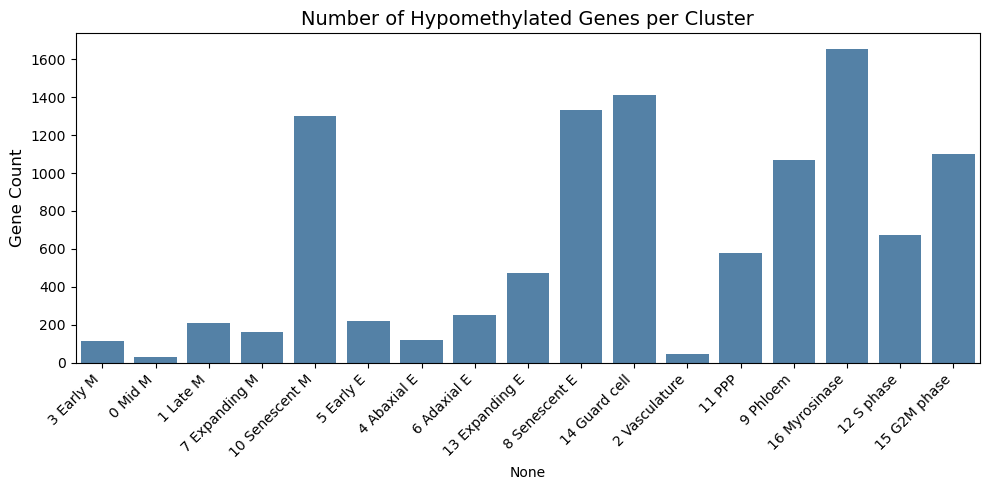

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Hypomethylation Summary ---")

# 1. Total unique genes flagged across all clusters
total_unique = len(all_hypo_results['Gene'].unique())
print(f"Total unique hypomethylated genes: {total_unique}")

# 2. Number of hypomethylated genes per cluster
# The .count() method automatically ignores NaN values
genes_per_cluster = hypo_genes_by_cluster_df.count()
print("\nNumber of hypomethylated genes per cluster:")
print(genes_per_cluster.to_string())

# 3. How many clusters is a single gene hypomethylated in?
# This counts how often each gene appears in the master list
cluster_counts_per_gene = all_hypo_results['Gene'].value_counts()
print("\nDistribution of events per gene:")
print("Clusters : Number of Genes")
print(cluster_counts_per_gene.value_counts().sort_index().to_string())

# --- Quick Visualization ---
plt.figure(figsize=(10, 5))
sns.barplot(x=genes_per_cluster.index, y=genes_per_cluster.values, color='steelblue')
plt.title("Number of Hypomethylated Genes per Cluster", fontsize=14)
plt.ylabel("Gene Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()